In [1]:
# Python
import pandas as pd
from prophet import Prophet


In [8]:
# Python
df = pd.read_csv('BayesianAR2Forecasts.csv')[['year','annual_mean']].head(36)
df.columns=['ds','y']
df['ds'] = pd.to_datetime(df['ds'],format='%Y')
df.tail()

,ds,y
31,2020-01-01,93.0
32,2021-01-01,106.0
33,2022-01-01,99.7
34,2023-01-01,103.3
35,2024-01-01,101.6


In [9]:
# Python
m = Prophet()
m.fit(df)

09:16:42 - cmdstanpy - INFO - Chain [1] start processing
09:16:42 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
future = m.make_future_dataframe(periods=10, freq='YS')
future.tail()

,ds
41,2030-01-01
42,2031-01-01
43,2032-01-01
44,2033-01-01
45,2034-01-01


In [15]:
# Python
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
41,2030-01-01,107.571030,85.088614,129.393106
42,2031-01-01,107.394776,85.114834,130.776090
43,2032-01-01,105.734811,84.138193,126.382236
44,2033-01-01,102.914010,81.074467,125.098780
45,2034-01-01,104.220934,82.462196,125.376407


In [19]:
prophet_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

In [25]:
prophet_forecast['year']= prophet_forecast.ds.dt.year

/tmp/ipykernel_7326/2692620742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prophet_forecast['year']= prophet_forecast.ds.dt.year


In [32]:
df = pd.read_csv('BayesianAR2Forecasts.csv')[['year','annual_mean']].head(36)

prophet_forecast = prophet_forecast[['year', 'yhat', 'yhat_lower', 'yhat_upper']].merge(df,on='year',how='left')

In [37]:
prophet_forecast = prophet_forecast[['year','annual_mean','yhat','yhat_lower','yhat_upper']]
prophet_forecast.columns= ['year','annual_mean_obs','yhat','yhat_lower','yhat_upper']

In [39]:
prophet_forecast.to_csv('ProphetForecasts.csv',index=False)

In [46]:
import numpy as np 


array([134.3, 121.7, 114.1, 135.7, 133.9, 135.7, 146.5, 139.3, 133.2,
       133.2, 126. , 111. , 110. , 165. , 154. , 135. , 154. , 171. ,
       111.1, 138.6,  91.5, 144.1, 140.1, 140.3, 125.3, 117.2, 125.3,
       133.3, 117.2, 120. , 105. ,  93. , 106. ,  99.7, 103.3, 101.6])

In [56]:
prophet_forecast

,year,annual_mean_obs,yhat,yhat_lower,yhat_upper
0,1989,134.3,139.731698,118.388286,160.658654
1,1990,121.7,141.040318,120.350010,163.238155
2,1991,114.1,140.865759,119.275034,163.199910
3,1992,135.7,139.207489,116.020801,160.209674
4,1993,133.9,136.388387,115.859036,156.995264
5,1994,135.7,137.697006,115.062825,159.980307
6,1995,146.5,137.522448,115.137130,159.581670
7,1996,139.3,135.864178,115.329357,157.003296
8,1997,133.2,133.045076,111.978177,155.936228
9,1998,133.2,134.353695,112.771271,156.340677


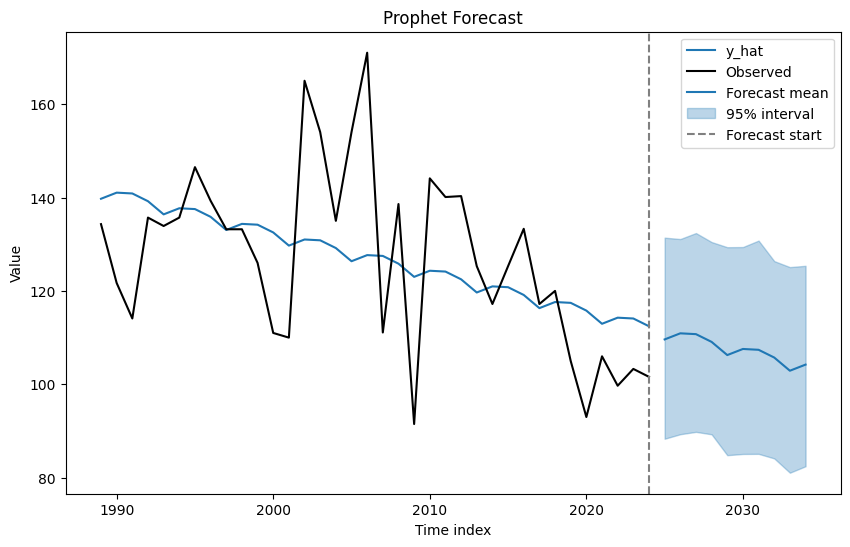

In [68]:
import matplotlib.pyplot as plt
# Combine observed + forecast
observed = np.array(prophet_forecast.annual_mean_obs.dropna())
yhat= np.array(prophet_forecast[:36]['yhat'])
x_obs = np.array(prophet_forecast.year[:36])

x_forecast = np.array(prophet_forecast.year[36:])
forecast_mean = np.array(prophet_forecast[36:]['yhat'])
forecast_lower = np.array(prophet_forecast[36:]['yhat_lower'])
forecast_upper = np.array(prophet_forecast[36:]['yhat_upper'])
n_forecast = 10
#x_obs = np.arange(len(observed))
#x_forecast = np.arange(len(observed), len(observed) + n_forecast)

plt.figure(figsize=(10, 6))
plt.plot(x_obs, yhat, label="y_hat", color="tab:blue")
plt.plot(x_obs, observed, label="Observed", color="black")
plt.plot(x_forecast, forecast_mean, label="Forecast mean", color="tab:blue")
plt.fill_between(x_forecast, forecast_lower, forecast_upper,
                 color="tab:blue", alpha=0.3, label="95% interval")

plt.axvline(2024, color='gray', linestyle='--', label='Forecast start')
plt.legend()
plt.xlabel("Time index")
plt.ylabel("Value")
plt.title("Prophet Forecast")
plt.show()

In [62]:
x_obs = np.array(prophet_forecast.year[:36])


In [66]:
x_forecast

array([2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034],
      dtype=int32)

In [63]:
x_obs

array([1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,
       2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024], dtype=int32)